# Overlap Group-Rep Signature Similarity

This notebook starts from the overlap-filtered `.h5ad` files produced by `scripts/build_overlap_filtered_h5ads.py` to determine the retained lines and matched grouped-replicate samples, then loads the corresponding per-line DE files from the source result directories.

For each dataset pair, it reconstructs matches using the same rule as the overlap script / heatmap notebook:

- same `pubchem_cid`
- same `cell_type`
- same `pert_time_h`
- mutual nearest neighbors in `log10(pert_dose_uM)`
- `|Δ log10 dose| <= 1`
- a `cell_type + pert_time_h` context is included for a dataset pair only if that pair shares at least `10` matched drugs in that context

For every matched grouped-replicate sample pair, the notebook computes:

- signed Spearman correlation across genes on `logFC`
- signed Spearman correlation across genes on `t`
- signed overlap@50 on `t`, using the top 50 and bottom 50 genes

All signature metrics are computed twice:

- on the usual pairwise shared gene set for that dataset pair / line comparison
- on the line-specific multi-dataset gene set for that `cell_type`, defined as the genes shared across all active datasets that retain that line, exposed via `*_global` columns in the saved tables

It also computes a baseline for each matched sample: the average signature across other non-control compounds from the same dataset, line, dose, and time. Baseline metrics are evaluated on the same gene space as the corresponding observed metric, both for the pairwise shared-gene evaluation and for the line-specific multi-dataset shared-gene evaluation.

For summary tables, matched sample pairs are first averaged within each `pubchem_cid + cell_type + pert_time_h` case across all matched doses, then those drug-line-time cases are averaged to get the dataset-pair and dataset-pair-line summaries.

Outputs are written to `results/overlap_signature_similarity_group_rep/`.


In [21]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
import itertools

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import rankdata


sns.set_theme(style="whitegrid")


In [22]:
DATASET_ORDER = [
    "l1000_phase1",
    "l1000_phase2",
    "sciplex",
    "tahoe",
]
DISPLAY_LABELS = {
    "l1000_phase1": "L1000 Phase I",
    "l1000_phase2": "L1000 Phase II",
    "sciplex": "sci-Plex",
    "tahoe": "Tahoe-100M",
}
SOURCE_DATASET_DIRS = {
    "sciplex": Path("/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/sciplex/deg_data/group_rep/full/qc_false/filter_min_cells_10/results"),
    "tahoe": Path("/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/tahoe/deg_data/group_rep/full/qc_false/filter_min_cells_50/results"),
    "l1000_phase1": Path("/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/l1000_phase1/deg_data/group_rep/full/qc_false/filter_min_cells_0/results"),
    "l1000_phase2": Path("/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/l1000_phase2/deg_data/group_rep/full/qc_false/filter_min_cells_0/results"),
}
MAX_LOG10_DOSE_DIFF = 1.0
MIN_CONTEXT_SHARED_DRUGS = 10
TOP_K = 50
NUMERIC_SIG_FIGS = 12


def find_repo_root(start=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "overlap_filtered_h5ads").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()
OVERLAP_DIR = REPO_ROOT / "results" / "overlap_filtered_h5ads"
OUTPUT_DIR = REPO_ROOT / "results" / "overlap_signature_similarity_group_rep"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Overlap directory: {OVERLAP_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Repository root: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis
Overlap directory: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_filtered_h5ads
Output directory: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep


In [23]:
def pretty_label(dataset_name: str) -> str:
    return DISPLAY_LABELS.get(dataset_name, dataset_name)


def format_numeric(value: float) -> str:
    formatted = f"{value:.{NUMERIC_SIG_FIGS}g}"
    return "0" if formatted == "-0" else formatted


def coerce_control_mask(values: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(values):
        return values.fillna(False).astype(bool)
    normalized = values.astype("string").fillna("").astype(str).str.strip().str.lower()
    return normalized.isin({"true", "1", "yes"})


EMPTY_OVERLAP_FRAME = pd.DataFrame(
    columns=[
        "dataset_name",
        "obs_id",
        "plate",
        "well",
        "pubchem_cid",
        "cell_type",
        "pert_time_h",
        "pert_dose_uM",
        "time_key",
        "dose_key",
        "log10_dose",
    ]
)


def load_overlap_obs(dataset_name: str, overlap_dir: Path = OVERLAP_DIR) -> pd.DataFrame:
    h5ad_path = overlap_dir / f"{dataset_name}_overlap_filtered.h5ad"
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing overlap file: {h5ad_path}")

    adata = ad.read_h5ad(h5ad_path, backed="r")
    try:
        obs = adata.obs.copy()
    finally:
        adata.file.close()

    if obs.empty:
        return EMPTY_OVERLAP_FRAME.copy()
    if "is_control" not in obs.columns:
        raise KeyError(f"{h5ad_path} is missing obs['is_control']")

    obs = obs.loc[~coerce_control_mask(obs["is_control"])].copy()
    if obs.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame = pd.DataFrame(index=obs.index.copy())
    frame["dataset_name"] = dataset_name
    frame["obs_id"] = frame.index.astype(str)
    frame["plate"] = (
        obs["plate"].astype("string").fillna("").astype(str).str.strip()
        if "plate" in obs.columns
        else ""
    )
    frame["well"] = (
        obs["well"].astype("string").fillna("").astype(str).str.strip()
        if "well" in obs.columns
        else ""
    )
    frame["pubchem_cid"] = obs["pubchem_cid"].astype("string").fillna("").astype(str).str.strip()
    frame["cell_type"] = obs["cell_type"].astype("string").fillna("").astype(str).str.strip()
    frame["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    if frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    return frame[EMPTY_OVERLAP_FRAME.columns.tolist()]


def ensure_overlap_frame_schema(frame: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    if frame is None or frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame = frame.copy()
    if "dataset_name" not in frame.columns:
        frame["dataset_name"] = dataset_name
    else:
        frame["dataset_name"] = frame["dataset_name"].astype("string").fillna(dataset_name).astype(str).str.strip()

    if "obs_id" not in frame.columns:
        frame["obs_id"] = pd.Index(frame.index).astype(str)
    else:
        frame["obs_id"] = frame["obs_id"].astype("string").fillna("").astype(str).str.strip()

    for column_name in ["plate", "well"]:
        if column_name not in frame.columns:
            frame[column_name] = ""
        else:
            frame[column_name] = frame[column_name].astype("string").fillna("").astype(str).str.strip()

    required_columns = ["pubchem_cid", "cell_type", "pert_time_h", "pert_dose_uM"]
    missing_columns = [column_name for column_name in required_columns if column_name not in frame.columns]
    if missing_columns:
        raise KeyError(
            f"Overlap frame for {dataset_name} is missing required columns: {missing_columns}"
        )

    frame["pubchem_cid"] = frame["pubchem_cid"].astype("string").fillna("").astype(str).str.strip()
    frame["cell_type"] = frame["cell_type"].astype("string").fillna("").astype(str).str.strip()
    frame["pert_time_h"] = pd.to_numeric(frame["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(frame["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    if frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    return frame[EMPTY_OVERLAP_FRAME.columns.tolist()]


def build_groups(frame: pd.DataFrame) -> dict[tuple[str, str, str], np.ndarray]:
    if frame.empty:
        return {}
    grouped = frame.groupby(["pubchem_cid", "cell_type", "time_key"], sort=False).groups
    return {
        key: np.asarray(list(row_positions), dtype=np.int64)
        for key, row_positions in grouped.items()
    }


def build_dataset_index(dataset_name: str) -> dict[str, object]:
    frame = ensure_overlap_frame_schema(load_overlap_obs(dataset_name), dataset_name)
    return {
        "frame": frame,
        "groups": build_groups(frame),
    }


def active_dataset_names(dataset_indices: dict[str, dict[str, object]]) -> list[str]:
    return [
        dataset_name
        for dataset_name in DATASET_ORDER
        if dataset_name in dataset_indices and not dataset_indices[dataset_name]["frame"].empty
    ]


def mutual_nearest_logdose_pairs(
    left_log10_doses: np.ndarray,
    right_log10_doses: np.ndarray,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
) -> np.ndarray:
    if left_log10_doses.size == 0 or right_log10_doses.size == 0:
        return np.empty((0, 2), dtype=np.int64)

    diff = np.abs(left_log10_doses[:, None] - right_log10_doses[None, :])
    left_min = diff.min(axis=1, keepdims=True)
    right_min = diff.min(axis=0, keepdims=True)
    is_mnn = (
        (diff <= max_log10_dose_diff + 1e-12)
        & np.isclose(diff, left_min, rtol=0.0, atol=1e-12)
        & np.isclose(diff, right_min, rtol=0.0, atol=1e-12)
    )
    return np.argwhere(is_mnn)


MATCH_PAIR_COLUMNS = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "pubchem_cid",
    "time_key",
    "left_obs_id",
    "right_obs_id",
    "left_plate",
    "right_plate",
    "left_well",
    "right_well",
    "left_dose_key",
    "right_dose_key",
    "left_log10_dose",
    "right_log10_dose",
    "abs_delta_log10_dose",
    "matched_condition_key",
    "n_context_matching_drugs",
]


def pair_match_frame(
    left_dataset: str,
    right_dataset: str,
    left_index: dict[str, object],
    right_index: dict[str, object],
    *,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
    min_context_shared_drugs: int = MIN_CONTEXT_SHARED_DRUGS,
) -> pd.DataFrame:
    left_frame = ensure_overlap_frame_schema(left_index["frame"], left_dataset)
    right_frame = ensure_overlap_frame_schema(right_index["frame"], right_dataset)
    left_groups = left_index["groups"]
    right_groups = right_index["groups"]

    if set(build_groups(left_frame)) != set(left_groups):
        left_groups = build_groups(left_frame)
    if set(build_groups(right_frame)) != set(right_groups):
        right_groups = build_groups(right_frame)

    if left_frame.empty or right_frame.empty:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    shared_keys = sorted(set(left_groups) & set(right_groups))
    if not shared_keys:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    left_obs_ids = left_frame["obs_id"].to_numpy(dtype=object)
    right_obs_ids = right_frame["obs_id"].to_numpy(dtype=object)
    left_plates = left_frame["plate"].to_numpy(dtype=object)
    right_plates = right_frame["plate"].to_numpy(dtype=object)
    left_wells = left_frame["well"].to_numpy(dtype=object)
    right_wells = right_frame["well"].to_numpy(dtype=object)
    left_log10_dose = left_frame["log10_dose"].to_numpy(dtype=np.float64)
    right_log10_dose = right_frame["log10_dose"].to_numpy(dtype=np.float64)
    left_dose_keys = left_frame["dose_key"].to_numpy(dtype=object)
    right_dose_keys = right_frame["dose_key"].to_numpy(dtype=object)

    context_matching_drugs: dict[tuple[str, str], set[str]] = defaultdict(set)
    rows: list[dict[str, object]] = []

    for pubchem_cid, cell_type, time_key in shared_keys:
        left_rows = left_groups[(pubchem_cid, cell_type, time_key)]
        right_rows = right_groups[(pubchem_cid, cell_type, time_key)]
        pairs = mutual_nearest_logdose_pairs(
            left_log10_doses=left_log10_dose[left_rows],
            right_log10_doses=right_log10_dose[right_rows],
            max_log10_dose_diff=max_log10_dose_diff,
        )
        if pairs.size == 0:
            continue

        for left_pos, right_pos in pairs:
            left_row = int(left_rows[left_pos])
            right_row = int(right_rows[right_pos])
            left_dose_key = str(left_dose_keys[left_row])
            right_dose_key = str(right_dose_keys[right_row])
            context_matching_drugs[(str(cell_type), str(time_key))].add(str(pubchem_cid))
            rows.append(
                {
                    "dataset_a": left_dataset,
                    "dataset_b": right_dataset,
                    "cell_type": str(cell_type),
                    "pubchem_cid": str(pubchem_cid),
                    "time_key": str(time_key),
                    "left_obs_id": str(left_obs_ids[left_row]),
                    "right_obs_id": str(right_obs_ids[right_row]),
                    "left_plate": str(left_plates[left_row]),
                    "right_plate": str(right_plates[right_row]),
                    "left_well": str(left_wells[left_row]),
                    "right_well": str(right_wells[right_row]),
                    "left_dose_key": left_dose_key,
                    "right_dose_key": right_dose_key,
                    "left_log10_dose": float(left_log10_dose[left_row]),
                    "right_log10_dose": float(right_log10_dose[right_row]),
                    "abs_delta_log10_dose": float(abs(left_log10_dose[left_row] - right_log10_dose[right_row])),
                    "matched_condition_key": "|".join(
                        [
                            str(pubchem_cid),
                            str(cell_type),
                            str(time_key),
                            left_dose_key,
                            right_dose_key,
                        ]
                    ),
                }
            )

    if not rows:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    frame = pd.DataFrame(rows)
    qualifying_context_drug_counts = {
        context_key: len(compounds)
        for context_key, compounds in context_matching_drugs.items()
        if len(compounds) >= int(min_context_shared_drugs)
    }
    if not qualifying_context_drug_counts:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    frame["_context_key"] = list(zip(frame["cell_type"], frame["time_key"]))
    frame["n_context_matching_drugs"] = frame["_context_key"].map(qualifying_context_drug_counts)
    frame = frame.loc[frame["n_context_matching_drugs"].notna()].copy()
    frame["n_context_matching_drugs"] = frame["n_context_matching_drugs"].astype(int)
    frame = frame.drop(columns="_context_key")
    return frame[MATCH_PAIR_COLUMNS].reset_index(drop=True)


In [24]:
@dataclass
class LineSource:
    dataset_name: str
    cell_type: str
    path: Path
    adata: ad.AnnData = field(init=False, repr=False)
    obs: pd.DataFrame = field(init=False, repr=False)
    unique_gene_keys: np.ndarray = field(init=False, repr=False)
    unique_gene_positions: np.ndarray = field(init=False, repr=False)
    gene_to_pos: dict[str, int] = field(init=False, repr=False)
    lookup_row_pos: dict[str, int] = field(init=False, repr=False)
    _vector_cache: dict[tuple[str, int], np.ndarray] = field(default_factory=dict, init=False, repr=False)
    _baseline_cache: dict[tuple[str, int], object] = field(default_factory=dict, init=False, repr=False)
    _baseline_peer_counts: dict[int, int] = field(default_factory=dict, init=False, repr=False)

    def __post_init__(self) -> None:
        self.adata = ad.read_h5ad(self.path, backed="r")
        obs = self.adata.obs.copy()
        row_positions = np.arange(self.adata.n_obs, dtype=np.int64)

        if "is_control" not in obs.columns:
            raise KeyError(f"{self.path} is missing obs['is_control']")

        obs["source_index"] = obs.index.astype(str)
        control_mask = coerce_control_mask(obs["is_control"]).to_numpy(dtype=bool)
        obs = obs.loc[~control_mask].copy()
        row_positions = row_positions[~control_mask]

        obs["source_row_pos"] = row_positions
        for column_name in [
            "id",
            "plate",
            "well",
            "cell_type",
            "perturbagen",
            "perturbagen_name",
            "perturbation_label",
            "pubchem_cid",
        ]:
            if column_name in obs.columns:
                obs[column_name] = obs[column_name].astype("string").fillna("").astype(str).str.strip()

        obs["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
        obs["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")
        obs["time_key"] = obs["pert_time_h"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) else ""
        )
        obs["dose_key"] = obs["pert_dose_uM"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) and float(value) > 0 else ""
        )

        valid_mask = (
            (obs["pubchem_cid"] != "")
            & np.isfinite(obs["pert_time_h"].to_numpy(dtype=float))
            & np.isfinite(obs["pert_dose_uM"].to_numpy(dtype=float))
            & (obs["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
        )
        obs = obs.loc[valid_mask].copy()
        obs = obs.set_index("source_row_pos", drop=False)
        self.obs = obs
        self.lookup_row_pos = self._build_lookup_row_pos()

        var = self.adata.var.copy()
        if "symbol" in var.columns:
            gene_key_series = pd.Series(
                var["symbol"].astype("string").fillna("").astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        else:
            gene_key_series = pd.Series(
                pd.Index(self.adata.var_names.astype(str)).astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        keep_mask = (gene_key_series != "") & ~gene_key_series.duplicated(keep="first")
        self.unique_gene_positions = gene_key_series.index[keep_mask].to_numpy(dtype=np.int64)
        self.unique_gene_keys = gene_key_series.loc[keep_mask].to_numpy(dtype=object)
        self.gene_to_pos = {
            str(gene_key): int(pos)
            for pos, gene_key in enumerate(self.unique_gene_keys.tolist())
        }

    def _build_lookup_row_pos(self) -> dict[str, int]:
        lookup_row_pos: dict[str, int] = {}

        def add_lookup_key(key: str, row_pos: int) -> None:
            if not key or key.lower() == "nan":
                return
            lookup_row_pos.setdefault(key, row_pos)

        for row_pos, row in self.obs.iterrows():
            row_pos = int(row_pos)
            for column_name in ["source_index", "id"]:
                if column_name in row.index:
                    add_lookup_key(str(row[column_name]).strip(), row_pos)

            cell_type = str(row.get("cell_type", "")).strip()
            pubchem_cid = str(row.get("pubchem_cid", "")).strip()
            dose_key = str(row.get("dose_key", "")).strip()
            time_key = str(row.get("time_key", "")).strip()

            if pubchem_cid and dose_key and time_key and cell_type:
                add_lookup_key(
                    f"{pubchem_cid}|{dose_key}|{time_key}|{cell_type}",
                    row_pos,
                )
        return lookup_row_pos

    def resolve_row_pos(
        self,
        obs_id: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> int:
        obs_id = str(obs_id)
        candidate_keys = [obs_id]

        pubchem_cid = "" if pubchem_cid is None else str(pubchem_cid).strip()
        dose_key = "" if dose_key is None else str(dose_key).strip()
        time_key = "" if time_key is None else str(time_key).strip()

        if pubchem_cid and dose_key and time_key:
            candidate_keys.append(f"{pubchem_cid}|{dose_key}|{time_key}|{self.cell_type}")

        for candidate_key in candidate_keys:
            if candidate_key in self.lookup_row_pos:
                return int(self.lookup_row_pos[candidate_key])

        raise KeyError(
            f"Could not resolve obs_id={obs_id!r} in {self.path}. "
            f"Tried {candidate_keys!r}. Available lookup keys: {len(self.lookup_row_pos):,}"
        )

    def get_vector(
        self,
        obs_id: str,
        layer_name: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> np.ndarray:
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        cache_key = (layer_name, row_pos)
        if cache_key not in self._vector_cache:
            vector = np.asarray(self.adata.layers[layer_name][row_pos], dtype=np.float32).reshape(-1)
            self._vector_cache[cache_key] = vector[self.unique_gene_positions]
        return self._vector_cache[cache_key]

    def get_baseline_vector(
        self,
        obs_id: str,
        layer_name: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ):
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        cache_key = (layer_name, row_pos)
        if cache_key not in self._baseline_cache:
            row = self.obs.loc[row_pos]
            peer_obs = self.obs.loc[
                (self.obs["dose_key"] == row["dose_key"])
                & (self.obs["time_key"] == row["time_key"])
                & (self.obs["pubchem_cid"] != row["pubchem_cid"])
            ]
            peer_rows = peer_obs["source_row_pos"].to_numpy(dtype=np.int64)
            self._baseline_peer_counts[row_pos] = int(len(peer_rows))
            if len(peer_rows) == 0:
                self._baseline_cache[cache_key] = None
            else:
                matrix = np.asarray(self.adata.layers[layer_name][peer_rows], dtype=np.float32)
                if matrix.ndim == 1:
                    matrix = matrix[np.newaxis, :]
                baseline = matrix[:, self.unique_gene_positions].mean(axis=0, dtype=np.float64)
                self._baseline_cache[cache_key] = np.asarray(baseline, dtype=np.float32)
        return self._baseline_cache[cache_key]

    def baseline_peer_count(
        self,
        obs_id: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> int:
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        if row_pos not in self._baseline_peer_counts:
            _ = self.get_baseline_vector(
                obs_id,
                "logFC",
                pubchem_cid=pubchem_cid,
                dose_key=dose_key,
                time_key=time_key,
                plate=plate,
                well=well,
            )
        return int(self._baseline_peer_counts.get(row_pos, 0))

    def close(self) -> None:
        self.adata.file.close()


def resolve_line_path(dataset_name: str, cell_type: str) -> Path:
    dataset_dir = SOURCE_DATASET_DIRS[dataset_name]
    candidates = [
        dataset_dir / f"{cell_type}_de.h5ad",
        dataset_dir / f"{cell_type}.h5ad",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find a line file for dataset={dataset_name}, cell_type={cell_type} in {dataset_dir}"
    )


LINE_SOURCE_CACHE: dict[tuple[str, str], LineSource] = {}
COMMON_GENE_CACHE: dict[tuple[str, str, str], tuple[np.ndarray, np.ndarray, np.ndarray]] = {}


def get_line_source(dataset_name: str, cell_type: str) -> LineSource:
    cache_key = (dataset_name, cell_type)
    if cache_key not in LINE_SOURCE_CACHE:
        LINE_SOURCE_CACHE[cache_key] = LineSource(
            dataset_name=dataset_name,
            cell_type=cell_type,
            path=resolve_line_path(dataset_name, cell_type),
        )
    return LINE_SOURCE_CACHE[cache_key]


def shared_gene_positions(
    left_source: LineSource,
    right_source: LineSource,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    cache_key = (left_source.dataset_name, right_source.dataset_name, left_source.cell_type)
    if cache_key not in COMMON_GENE_CACHE:
        shared_genes = [
            gene_key
            for gene_key in left_source.unique_gene_keys.tolist()
            if str(gene_key) in right_source.gene_to_pos
        ]
        left_positions = np.fromiter(
            (left_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        right_positions = np.fromiter(
            (right_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        COMMON_GENE_CACHE[cache_key] = (
            np.asarray(shared_genes, dtype=object),
            left_positions,
            right_positions,
        )
    return COMMON_GENE_CACHE[cache_key]

LINE_GLOBAL_SHARED_GENE_KEYS: dict[str, np.ndarray] = {}
GLOBAL_GENE_POSITION_CACHE: dict[tuple[str, str], np.ndarray] = {}


def set_global_shared_gene_keys(
    retained_lines: dict[str, list[str]],
    dataset_names: list[str],
) -> dict[str, np.ndarray]:
    global LINE_GLOBAL_SHARED_GENE_KEYS, GLOBAL_GENE_POSITION_CACHE

    cell_types = sorted(
        {
            cell_type
            for dataset_name in dataset_names
            for cell_type in retained_lines.get(dataset_name, [])
        }
    )
    line_gene_map: dict[str, np.ndarray] = {}
    for cell_type in cell_types:
        gene_sets: list[set[str]] = []
        for dataset_name in dataset_names:
            if cell_type not in retained_lines.get(dataset_name, []):
                continue
            source = get_line_source(dataset_name, cell_type)
            gene_sets.append({str(gene_key) for gene_key in source.unique_gene_keys.tolist()})
        if not gene_sets:
            line_gene_map[cell_type] = np.empty(0, dtype=object)
        else:
            line_gene_map[cell_type] = np.asarray(sorted(set.intersection(*gene_sets)), dtype=object)

    LINE_GLOBAL_SHARED_GENE_KEYS = line_gene_map
    GLOBAL_GENE_POSITION_CACHE = {}
    return LINE_GLOBAL_SHARED_GENE_KEYS


def global_gene_positions(source: LineSource) -> tuple[np.ndarray, np.ndarray]:
    cache_key = (source.dataset_name, source.cell_type)
    line_gene_keys = LINE_GLOBAL_SHARED_GENE_KEYS.get(source.cell_type, np.empty(0, dtype=object))
    if line_gene_keys.size == 0:
        return line_gene_keys, np.empty(0, dtype=np.int64)
    if cache_key not in GLOBAL_GENE_POSITION_CACHE:
        missing_gene_keys = [
            str(gene_key)
            for gene_key in line_gene_keys.tolist()
            if str(gene_key) not in source.gene_to_pos
        ]
        if missing_gene_keys:
            raise KeyError(
                f"Line-specific shared-gene set is inconsistent for {(source.dataset_name, source.cell_type)}; "
                f"missing {len(missing_gene_keys)} genes."
            )
        GLOBAL_GENE_POSITION_CACHE[cache_key] = np.fromiter(
            (source.gene_to_pos[str(gene_key)] for gene_key in line_gene_keys.tolist()),
            dtype=np.int64,
            count=int(line_gene_keys.size),
        )
    return line_gene_keys, GLOBAL_GENE_POSITION_CACHE[cache_key]



def filter_finite_pair(left_values: np.ndarray, right_values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mask = np.isfinite(left_values) & np.isfinite(right_values)
    return left_values[mask], right_values[mask]


def signed_spearman(left_values: np.ndarray, right_values: np.ndarray) -> float:
    left_values, right_values = filter_finite_pair(
        np.asarray(left_values, dtype=np.float64),
        np.asarray(right_values, dtype=np.float64),
    )
    if left_values.size < 2:
        return float("nan")

    left_ranks = rankdata(left_values, method="average")
    right_ranks = rankdata(right_values, method="average")
    if np.allclose(left_ranks, left_ranks[0]) or np.allclose(right_ranks, right_ranks[0]):
        return float("nan")
    return float(np.corrcoef(left_ranks, right_ranks)[0, 1])


def signed_overlap_at_k(left_values: np.ndarray, right_values: np.ndarray, *, k: int = TOP_K) -> float:
    left_values, right_values = filter_finite_pair(
        np.asarray(left_values, dtype=np.float64),
        np.asarray(right_values, dtype=np.float64),
    )
    n_genes = int(left_values.size)
    k_eff = min(int(k), n_genes // 2)
    if k_eff < 1:
        return float("nan")

    top_left = np.argpartition(left_values, -k_eff)[-k_eff:]
    top_right = np.argpartition(right_values, -k_eff)[-k_eff:]
    bottom_left = np.argpartition(left_values, k_eff - 1)[:k_eff]
    bottom_right = np.argpartition(right_values, k_eff - 1)[:k_eff]

    top_overlap = np.intersect1d(top_left, top_right, assume_unique=False).size / k_eff
    bottom_overlap = np.intersect1d(bottom_left, bottom_right, assume_unique=False).size / k_eff
    return float(0.5 * (top_overlap + bottom_overlap))


def score_signature_pair(
    left_logfc: np.ndarray,
    right_logfc: np.ndarray,
    left_t: np.ndarray,
    right_t: np.ndarray,
) -> dict[str, float]:
    return {
        "spearman_logfc": signed_spearman(left_logfc, right_logfc),
        "spearman_t": signed_spearman(left_t, right_t),
        f"signed_overlap_t_top{TOP_K}": signed_overlap_at_k(left_t, right_t, k=TOP_K),
    }


def mean_available(values: list[float]) -> float:
    finite_values = [value for value in values if pd.notna(value)]
    if not finite_values:
        return float("nan")
    return float(np.mean(finite_values))

def empty_score_dict() -> dict[str, float]:
    return {
        "spearman_logfc": float("nan"),
        "spearman_t": float("nan"),
        f"signed_overlap_t_top{TOP_K}": float("nan"),
    }



def compute_metric_record(match_row: pd.Series) -> dict[str, object]:
    left_source = get_line_source(str(match_row["dataset_a"]), str(match_row["cell_type"]))
    right_source = get_line_source(str(match_row["dataset_b"]), str(match_row["cell_type"]))
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        raise ValueError(
            f"Fewer than two shared genes for {match_row['dataset_a']} vs {match_row['dataset_b']} / {match_row['cell_type']}"
        )

    global_shared_genes, left_global_gene_pos = global_gene_positions(left_source)
    _, right_global_gene_pos = global_gene_positions(right_source)

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])

    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_logfc_full = left_source.get_vector(left_obs_id, "logFC", **left_lookup)
    right_logfc_full = right_source.get_vector(right_obs_id, "logFC", **right_lookup)
    left_t_full = left_source.get_vector(left_obs_id, "t", **left_lookup)
    right_t_full = right_source.get_vector(right_obs_id, "t", **right_lookup)

    observed_scores = score_signature_pair(
        left_logfc=left_logfc_full[left_gene_pos],
        right_logfc=right_logfc_full[right_gene_pos],
        left_t=left_t_full[left_gene_pos],
        right_t=right_t_full[right_gene_pos],
    )

    observed_scores_global = empty_score_dict()
    if global_shared_genes.size >= 2:
        observed_scores_global = score_signature_pair(
            left_logfc=left_logfc_full[left_global_gene_pos],
            right_logfc=right_logfc_full[right_global_gene_pos],
            left_t=left_t_full[left_global_gene_pos],
            right_t=right_t_full[right_global_gene_pos],
        )

    left_mean_abs_t = mean_available(np.abs(left_t_full[left_gene_pos]).tolist())
    right_mean_abs_t = mean_available(np.abs(right_t_full[right_gene_pos]).tolist())
    pair_mean_abs_t = mean_available([left_mean_abs_t, right_mean_abs_t])

    left_mean_abs_t_global = float("nan")
    right_mean_abs_t_global = float("nan")
    pair_mean_abs_t_global = float("nan")
    if global_shared_genes.size >= 2:
        left_mean_abs_t_global = mean_available(np.abs(left_t_full[left_global_gene_pos]).tolist())
        right_mean_abs_t_global = mean_available(np.abs(right_t_full[right_global_gene_pos]).tolist())
        pair_mean_abs_t_global = mean_available([left_mean_abs_t_global, right_mean_abs_t_global])

    left_baseline_logfc_full = left_source.get_baseline_vector(left_obs_id, "logFC", **left_lookup)
    left_baseline_t_full = left_source.get_baseline_vector(left_obs_id, "t", **left_lookup)
    right_baseline_logfc_full = right_source.get_baseline_vector(right_obs_id, "logFC", **right_lookup)
    right_baseline_t_full = right_source.get_baseline_vector(right_obs_id, "t", **right_lookup)

    left_baseline_scores = empty_score_dict()
    left_baseline_scores_global = empty_score_dict()
    if left_baseline_logfc_full is not None and left_baseline_t_full is not None:
        left_baseline_scores = score_signature_pair(
            left_logfc=left_logfc_full[left_gene_pos],
            right_logfc=left_baseline_logfc_full[left_gene_pos],
            left_t=left_t_full[left_gene_pos],
            right_t=left_baseline_t_full[left_gene_pos],
        )
        if global_shared_genes.size >= 2:
            left_baseline_scores_global = score_signature_pair(
                left_logfc=left_logfc_full[left_global_gene_pos],
                right_logfc=left_baseline_logfc_full[left_global_gene_pos],
                left_t=left_t_full[left_global_gene_pos],
                right_t=left_baseline_t_full[left_global_gene_pos],
            )

    right_baseline_scores = empty_score_dict()
    right_baseline_scores_global = empty_score_dict()
    if right_baseline_logfc_full is not None and right_baseline_t_full is not None:
        right_baseline_scores = score_signature_pair(
            left_logfc=right_logfc_full[right_gene_pos],
            right_logfc=right_baseline_logfc_full[right_gene_pos],
            left_t=right_t_full[right_gene_pos],
            right_t=right_baseline_t_full[right_gene_pos],
        )
        if global_shared_genes.size >= 2:
            right_baseline_scores_global = score_signature_pair(
                left_logfc=right_logfc_full[right_global_gene_pos],
                right_logfc=right_baseline_logfc_full[right_global_gene_pos],
                left_t=right_t_full[right_global_gene_pos],
                right_t=right_baseline_t_full[right_global_gene_pos],
            )

    overlap_column = f"signed_overlap_t_top{TOP_K}"
    return {
        **match_row.to_dict(),
        "n_common_genes": int(shared_genes.size),
        "n_global_common_genes": int(global_shared_genes.size),
        "left_mean_abs_t": left_mean_abs_t,
        "right_mean_abs_t": right_mean_abs_t,
        "pair_mean_abs_t": pair_mean_abs_t,
        "left_mean_abs_t_global": left_mean_abs_t_global,
        "right_mean_abs_t_global": right_mean_abs_t_global,
        "pair_mean_abs_t_global": pair_mean_abs_t_global,
        "observed_spearman_logfc": observed_scores["spearman_logfc"],
        "observed_spearman_logfc_global": observed_scores_global["spearman_logfc"],
        "observed_spearman_t": observed_scores["spearman_t"],
        "observed_spearman_t_global": observed_scores_global["spearman_t"],
        f"observed_{overlap_column}": observed_scores[overlap_column],
        f"observed_{overlap_column}_global": observed_scores_global[overlap_column],
        "left_baseline_peer_count": left_source.baseline_peer_count(left_obs_id, **left_lookup),
        "left_baseline_spearman_logfc": left_baseline_scores["spearman_logfc"],
        "left_baseline_spearman_logfc_global": left_baseline_scores_global["spearman_logfc"],
        "left_baseline_spearman_t": left_baseline_scores["spearman_t"],
        "left_baseline_spearman_t_global": left_baseline_scores_global["spearman_t"],
        f"left_baseline_{overlap_column}": left_baseline_scores[overlap_column],
        f"left_baseline_{overlap_column}_global": left_baseline_scores_global[overlap_column],
        "right_baseline_peer_count": right_source.baseline_peer_count(right_obs_id, **right_lookup),
        "right_baseline_spearman_logfc": right_baseline_scores["spearman_logfc"],
        "right_baseline_spearman_logfc_global": right_baseline_scores_global["spearman_logfc"],
        "right_baseline_spearman_t": right_baseline_scores["spearman_t"],
        "right_baseline_spearman_t_global": right_baseline_scores_global["spearman_t"],
        f"right_baseline_{overlap_column}": right_baseline_scores[overlap_column],
        f"right_baseline_{overlap_column}_global": right_baseline_scores_global[overlap_column],
        "baseline_pair_mean_spearman_logfc": mean_available(
            [left_baseline_scores["spearman_logfc"], right_baseline_scores["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_logfc_global": mean_available(
            [left_baseline_scores_global["spearman_logfc"], right_baseline_scores_global["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_t": mean_available(
            [left_baseline_scores["spearman_t"], right_baseline_scores["spearman_t"]]
        ),
        "baseline_pair_mean_spearman_t_global": mean_available(
            [left_baseline_scores_global["spearman_t"], right_baseline_scores_global["spearman_t"]]
        ),
        f"baseline_pair_mean_{overlap_column}": mean_available(
            [left_baseline_scores[overlap_column], right_baseline_scores[overlap_column]]
        ),
        f"baseline_pair_mean_{overlap_column}_global": mean_available(
            [left_baseline_scores_global[overlap_column], right_baseline_scores_global[overlap_column]]
        ),
    }

def close_all_line_sources() -> None:
    for line_source in LINE_SOURCE_CACHE.values():
        line_source.close()


In [25]:
dataset_indices = {dataset_name: build_dataset_index(dataset_name) for dataset_name in DATASET_ORDER}
active_datasets = active_dataset_names(dataset_indices)
if not active_datasets:
    raise ValueError("No overlap-filtered non-control samples were found for the configured datasets.")

print("Datasets in scope:", ", ".join(pretty_label(dataset_name) for dataset_name in active_datasets))

retained_lines = {
    dataset_name: sorted(dataset_indices[dataset_name]["frame"]["cell_type"].unique().tolist())
    for dataset_name in active_datasets
}
retained_lines_display = pd.DataFrame(
    {
        "dataset": [pretty_label(dataset_name) for dataset_name in retained_lines],
        "cell_types": [", ".join(lines) for lines in retained_lines.values()],
    }
)
display(retained_lines_display)

line_global_gene_keys = set_global_shared_gene_keys(retained_lines, active_datasets)
line_global_gene_counts = {
    cell_type: int(gene_keys.size)
    for cell_type, gene_keys in line_global_gene_keys.items()
}
print(f"Line-specific shared-gene sets computed for {len(line_global_gene_counts):,} retained lines.")
if not line_global_gene_counts or max(line_global_gene_counts.values()) < 2:
    print(
        "Line-specific shared-gene evaluation will be unavailable because no retained line has at least two genes shared across the datasets that retain it."
    )
else:
    print(
        f"Line-specific shared-gene count range across retained lines: {min(line_global_gene_counts.values()):,} to {max(line_global_gene_counts.values()):,}"
    )

pair_match_frames: list[pd.DataFrame] = []
for dataset_a, dataset_b in itertools.combinations(active_datasets, 2):
    frame = pair_match_frame(
        left_dataset=dataset_a,
        right_dataset=dataset_b,
        left_index=dataset_indices[dataset_a],
        right_index=dataset_indices[dataset_b],
    )
    if not frame.empty:
        pair_match_frames.append(frame)

if not pair_match_frames:
    raise ValueError("No matched grouped-replicate sample pairs were found.")

matched_pairs = pd.concat(pair_match_frames, ignore_index=True)
matched_pairs_path = OUTPUT_DIR / "matched_sample_pairs.tsv"
matched_pairs.to_csv(matched_pairs_path, sep="\t", index=False)
print(f"Saved matched sample pairs to {matched_pairs_path}")

pair_match_summary = (
    matched_pairs.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        n_matching_drugs=("pubchem_cid", "nunique"),
        n_matching_lines=("cell_type", "nunique"),
        n_matching_conditions=("matched_condition_key", "nunique"),
    )
)
pair_match_summary_display = pair_match_summary.copy()
pair_match_summary_display["dataset_a"] = pair_match_summary_display["dataset_a"].map(pretty_label)
pair_match_summary_display["dataset_b"] = pair_match_summary_display["dataset_b"].map(pretty_label)
display(pair_match_summary_display)

line_match_summary = (
    matched_pairs.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        n_matching_drugs=("pubchem_cid", "nunique"),
        n_matching_conditions=("matched_condition_key", "nunique"),
    )
    .sort_values(["dataset_a", "dataset_b", "cell_type"]) 
    .reset_index(drop=True)
)
line_match_summary_display = line_match_summary.copy()
line_match_summary_display["dataset_a"] = line_match_summary_display["dataset_a"].map(pretty_label)
line_match_summary_display["dataset_b"] = line_match_summary_display["dataset_b"].map(pretty_label)
display(line_match_summary_display)


Datasets in scope: L1000 Phase I, L1000 Phase II, sci-Plex, Tahoe-100M


,dataset,cell_types
0,L1000 Phase I,"CVCL_0023, CVCL_0031, CVCL_0320, CVCL_0332"
1,L1000 Phase II,"CVCL_0023, CVCL_0031, CVCL_0320"
2,sci-Plex,"CVCL_0023, CVCL_0031"
3,Tahoe-100M,"CVCL_0023, CVCL_0320, CVCL_0332"


/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.o

Line-specific shared-gene sets computed for 4 retained lines.
Line-specific shared-gene count range across retained lines: 599 to 941
Saved matched sample pairs to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep/matched_sample_pairs.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_drugs,n_matching_lines,n_matching_conditions
0,L1000 Phase I,L1000 Phase II,10855,190,3,375
1,L1000 Phase I,sci-Plex,2695,90,2,291
2,L1000 Phase I,Tahoe-100M,610,86,3,152
3,L1000 Phase II,sci-Plex,3192,83,2,381
4,L1000 Phase II,Tahoe-100M,1473,110,2,402
5,sci-Plex,Tahoe-100M,170,23,1,69


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237
1,L1000 Phase I,L1000 Phase II,CVCL_0031,2656,57,124
2,L1000 Phase I,L1000 Phase II,CVCL_0320,150,12,14
3,L1000 Phase I,sci-Plex,CVCL_0023,904,75,113
4,L1000 Phase I,sci-Plex,CVCL_0031,1791,90,178
5,L1000 Phase I,Tahoe-100M,CVCL_0023,402,83,95
6,L1000 Phase I,Tahoe-100M,CVCL_0320,96,20,24
7,L1000 Phase I,Tahoe-100M,CVCL_0332,112,11,33
8,L1000 Phase II,sci-Plex,CVCL_0023,1400,44,132
9,L1000 Phase II,sci-Plex,CVCL_0031,1792,83,249


In [26]:
metric_records: list[dict[str, object]] = []
unresolved_records: list[dict[str, object]] = []
context_join_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "left_dose_key",
    "right_dose_key",
]
for (dataset_a, dataset_b, cell_type, time_key, left_dose_key, right_dose_key), group in matched_pairs.groupby(
    context_join_columns,
    sort=False,
):
    print(
        f"Scoring {pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / time={time_key} / doses={left_dose_key} vs {right_dose_key}: "
        f"{len(group)} matched sample pairs across {group['pubchem_cid'].nunique()} shared compounds"
    )
    for _, match_row in group.iterrows():
        try:
            metric_records.append(compute_metric_record(match_row))
        except KeyError as exc:
            unresolved_records.append(
                {
                    **match_row.to_dict(),
                    "error": str(exc),
                }
            )

matched_pair_metrics = pd.DataFrame(metric_records)
if matched_pair_metrics.empty:
    raise ValueError("No matched sample pairs could be resolved in the source line files.")

matched_pair_metrics_path = OUTPUT_DIR / "matched_sample_pair_metrics.tsv"
matched_pair_metrics.to_csv(matched_pair_metrics_path, sep="	", index=False)
print(f"Saved matched sample pair metrics to {matched_pair_metrics_path}")
print(f"Scored {len(matched_pair_metrics):,} matched sample pairs")

unresolved_matches = pd.DataFrame(unresolved_records)
if unresolved_matches.empty:
    print("All matched sample pairs were resolved in the source line files.")
else:
    unresolved_matches_path = OUTPUT_DIR / "unresolved_matched_sample_pairs.tsv"
    unresolved_matches.to_csv(unresolved_matches_path, sep="	", index=False)
    print(
        f"Skipped {len(unresolved_matches):,} matched sample pairs with no corresponding grouped result in the source line files. "
        f"Saved details to {unresolved_matches_path}"
    )
    display(
        unresolved_matches.groupby(context_join_columns, as_index=False)
        .agg(n_unresolved=("error", "size"))
        .sort_values(context_join_columns)
        .reset_index(drop=True)
    )

matched_pair_metrics.head()


Scoring L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=10 vs 10: 5788 matched sample pairs across 128 shared compounds


Scoring L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=80 vs 10: 27 matched sample pairs across 2 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=9.1 vs 10: 9 matched sample pairs across 1 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=11.1 vs 10: 36 matched sample pairs across 3 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=10 vs 10: 2023 matched sample pairs across 57 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=2 vs 1.11: 132 matched sample pairs across 15 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=0.08 vs 0.12: 156 matched sample pairs across 18 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=3.32999992371 vs 3.33: 393 matched sample pairs across 14 shared compounds
Scoring L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24

,dataset_a,dataset_b,cell_type,time_key,left_dose_key,right_dose_key,n_unresolved
0,l1000_phase1,sciplex,CVCL_0023,24,0.119999997318,0.1,6
1,l1000_phase1,sciplex,CVCL_0023,24,10,10,6
2,l1000_phase1,sciplex,CVCL_0031,24,1.11000001431,1,6
3,l1000_phase1,sciplex,CVCL_0031,24,10,10,24
4,l1000_phase2,sciplex,CVCL_0023,24,1.11,1,22
5,l1000_phase2,sciplex,CVCL_0023,24,10,10,22
6,l1000_phase2,sciplex,CVCL_0031,24,1.11,1,8
7,l1000_phase2,sciplex,CVCL_0031,24,10,10,7


,dataset_a,dataset_b,cell_type,pubchem_cid,time_key,left_obs_id,right_obs_id,left_plate,right_plate,left_well,...,right_baseline_spearman_t,right_baseline_spearman_t_global,right_baseline_signed_overlap_t_top50,right_baseline_signed_overlap_t_top50_global,baseline_pair_mean_spearman_logfc,baseline_pair_mean_spearman_logfc_global,baseline_pair_mean_spearman_t,baseline_pair_mean_spearman_t_global,baseline_pair_mean_signed_overlap_t_top50,baseline_pair_mean_signed_overlap_t_top50_global
0,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X1_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X1_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275
1,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X2_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X2_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275
2,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X4_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X4_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275
3,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X6_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X6_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275
4,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X2_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X1_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X2_F1B6_DUO52HI53LO,LJP007_A549_24H_X1_F1B19,K20,...,0.231432,0.250305,0.19,0.21,0.323004,0.3275,0.34372,0.352676,0.295,0.275


In [27]:
overlap_metric_column = f"observed_signed_overlap_t_top{TOP_K}"
baseline_overlap_column = f"baseline_pair_mean_signed_overlap_t_top{TOP_K}"
left_baseline_overlap_column = f"left_baseline_signed_overlap_t_top{TOP_K}"
right_baseline_overlap_column = f"right_baseline_signed_overlap_t_top{TOP_K}"
drug_line_time_group_columns = ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid"]

metric_mean_columns = {
    "mean_common_genes": "n_common_genes",
    "mean_global_common_genes": "n_global_common_genes",
    "mean_left_mean_abs_t": "left_mean_abs_t",
    "mean_right_mean_abs_t": "right_mean_abs_t",
    "mean_pair_mean_abs_t": "pair_mean_abs_t",
    "mean_left_mean_abs_t_global": "left_mean_abs_t_global",
    "mean_right_mean_abs_t_global": "right_mean_abs_t_global",
    "mean_pair_mean_abs_t_global": "pair_mean_abs_t_global",
    "mean_observed_spearman_logfc": "observed_spearman_logfc",
    "mean_observed_spearman_logfc_global": "observed_spearman_logfc_global",
    "mean_observed_spearman_t": "observed_spearman_t",
    "mean_observed_spearman_t_global": "observed_spearman_t_global",
    f"mean_observed_signed_overlap_t_top{TOP_K}": overlap_metric_column,
    f"mean_observed_signed_overlap_t_top{TOP_K}_global": f"{overlap_metric_column}_global",
    "mean_baseline_pair_spearman_logfc": "baseline_pair_mean_spearman_logfc",
    "mean_baseline_pair_spearman_logfc_global": "baseline_pair_mean_spearman_logfc_global",
    "mean_baseline_pair_spearman_t": "baseline_pair_mean_spearman_t",
    "mean_baseline_pair_spearman_t_global": "baseline_pair_mean_spearman_t_global",
    f"mean_baseline_pair_signed_overlap_t_top{TOP_K}": baseline_overlap_column,
    f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global": f"{baseline_overlap_column}_global",
    "mean_left_baseline_spearman_logfc": "left_baseline_spearman_logfc",
    "mean_left_baseline_spearman_logfc_global": "left_baseline_spearman_logfc_global",
    "mean_left_baseline_spearman_t": "left_baseline_spearman_t",
    "mean_left_baseline_spearman_t_global": "left_baseline_spearman_t_global",
    f"mean_left_baseline_signed_overlap_t_top{TOP_K}": left_baseline_overlap_column,
    f"mean_left_baseline_signed_overlap_t_top{TOP_K}_global": f"{left_baseline_overlap_column}_global",
    "mean_right_baseline_spearman_logfc": "right_baseline_spearman_logfc",
    "mean_right_baseline_spearman_logfc_global": "right_baseline_spearman_logfc_global",
    "mean_right_baseline_spearman_t": "right_baseline_spearman_t",
    "mean_right_baseline_spearman_t_global": "right_baseline_spearman_t_global",
    f"mean_right_baseline_signed_overlap_t_top{TOP_K}": right_baseline_overlap_column,
    f"mean_right_baseline_signed_overlap_t_top{TOP_K}_global": f"{right_baseline_overlap_column}_global",
    "mean_left_baseline_peer_count": "left_baseline_peer_count",
    "mean_right_baseline_peer_count": "right_baseline_peer_count",
}

drug_line_time_agg = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for target_column, source_column in metric_mean_columns.items():
    drug_line_time_agg[target_column] = (source_column, "mean")
drug_line_time_agg["n_pair_baselines_available"] = (
    "baseline_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
drug_line_time_agg["n_pair_baselines_available_global"] = (
    "baseline_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

drug_line_time_metric_summary = (
    matched_pair_metrics.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**drug_line_time_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
drug_line_time_metric_summary_path = OUTPUT_DIR / "matched_drug_line_time_metric_summary.tsv"
drug_line_time_metric_summary.to_csv(drug_line_time_metric_summary_path, sep="	", index=False)
print(f"Saved drug-line-time metric summary to {drug_line_time_metric_summary_path}")

summary_mean_columns = [
    column_name for column_name in drug_line_time_metric_summary.columns if column_name.startswith("mean_")
]

pair_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_columns:
    pair_agg[column_name] = (column_name, "mean")
pair_agg["n_pair_baselines_available"] = (
    "mean_baseline_pair_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
pair_agg["n_pair_baselines_available_global"] = (
    "mean_baseline_pair_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

pair_metric_summary = (
    drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

line_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_columns:
    line_agg[column_name] = (column_name, "mean")
line_agg["n_pair_baselines_available"] = (
    "mean_baseline_pair_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
line_agg["n_pair_baselines_available_global"] = (
    "mean_baseline_pair_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

line_metric_summary = (
    drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**line_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

pair_metric_summary_path = OUTPUT_DIR / "dataset_pair_metric_summary.tsv"
line_metric_summary_path = OUTPUT_DIR / "dataset_pair_line_metric_summary.tsv"
pair_metric_summary.to_csv(pair_metric_summary_path, sep="	", index=False)
line_metric_summary.to_csv(line_metric_summary_path, sep="	", index=False)
print(f"Saved dataset-pair summary to {pair_metric_summary_path}")
print(f"Saved dataset-pair-line summary to {line_metric_summary_path}")

pair_metric_summary_display = pair_metric_summary.copy()
pair_metric_summary_display["dataset_a"] = pair_metric_summary_display["dataset_a"].map(pretty_label)
pair_metric_summary_display["dataset_b"] = pair_metric_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_summary_display)

line_metric_summary_display = line_metric_summary.copy()
line_metric_summary_display["dataset_a"] = line_metric_summary_display["dataset_a"].map(pretty_label)
line_metric_summary_display["dataset_b"] = line_metric_summary_display["dataset_b"].map(pretty_label)
display(line_metric_summary_display)


Saved drug-line-time metric summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep/matched_drug_line_time_metric_summary.tsv
Saved dataset-pair summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep/dataset_pair_metric_summary.tsv
Saved dataset-pair-line summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep/dataset_pair_line_metric_summary.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_common_genes,mean_global_common_genes,mean_left_mean_abs_t,...,mean_right_baseline_spearman_logfc,mean_right_baseline_spearman_logfc_global,mean_right_baseline_spearman_t,mean_right_baseline_spearman_t_global,mean_right_baseline_signed_overlap_t_top50,mean_right_baseline_signed_overlap_t_top50_global,mean_left_baseline_peer_count,mean_right_baseline_peer_count,n_pair_baselines_available,n_pair_baselines_available_global
0,L1000 Phase I,L1000 Phase II,10855,3,190,375,232,978.000000,693.590517,1.421906,...,0.321919,0.319214,0.333496,0.330557,0.256385,0.282808,3911.899551,633.734872,232,232
1,L1000 Phase I,sci-Plex,2653,2,90,285,162,776.790123,769.024691,1.376499,...,0.242426,0.242382,0.245101,0.245165,0.177142,0.178183,4272.128825,180.745964,162,162
2,L1000 Phase I,Tahoe-100M,610,3,86,152,114,940.903509,691.903509,1.112814,...,0.378645,0.398448,0.399722,0.411569,0.219842,0.259364,3189.242168,377.705044,114,114
3,L1000 Phase II,sci-Plex,3133,2,83,375,127,809.448819,803.559055,1.198436,...,0.230082,0.230075,0.233876,0.233869,0.163084,0.164374,911.512599,182.581014,127,127
4,L1000 Phase II,Tahoe-100M,1473,2,110,402,134,941.000000,879.746269,0.937878,...,0.417183,0.422610,0.442152,0.445580,0.245722,0.255126,1266.545136,376.639239,134,134
5,sci-Plex,Tahoe-100M,170,1,23,69,23,6742.000000,599.000000,0.941433,...,0.456681,0.457836,0.471023,0.467804,0.123913,0.288200,180.463768,376.416667,23,23


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_common_genes,mean_global_common_genes,mean_left_mean_abs_t,...,mean_right_baseline_spearman_logfc,mean_right_baseline_spearman_logfc_global,mean_right_baseline_spearman_t,mean_right_baseline_spearman_t_global,mean_right_baseline_signed_overlap_t_top50,mean_right_baseline_signed_overlap_t_top50_global,mean_left_baseline_peer_count,mean_right_baseline_peer_count,n_pair_baselines_available,n_pair_baselines_available_global
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237,163,978.0,599.0,1.408337,...,0.364488,0.360175,0.378248,0.373357,0.279092,0.314775,3941.918881,280.824366,163,163
1,L1000 Phase I,L1000 Phase II,CVCL_0031,2656,57,124,57,978.0,912.0,1.486806,...,0.234801,0.235619,0.240305,0.242005,0.212290,0.216742,4488.507339,1466.909976,57,57
2,L1000 Phase I,L1000 Phase II,CVCL_0320,150,12,14,12,978.0,941.0,1.297943,...,0.157497,0.159891,0.168265,0.169807,0.157396,0.162396,765.250000,1469.854167,12,12
3,L1000 Phase I,sci-Plex,CVCL_0023,892,74,111,74,616.0,599.0,1.314957,...,0.249503,0.249407,0.244304,0.244444,0.185595,0.187872,3934.608742,178.602584,74,74
4,L1000 Phase I,sci-Plex,CVCL_0031,1761,88,174,88,912.0,912.0,1.428250,...,0.236475,0.236475,0.245771,0.245771,0.170035,0.170035,4555.952531,182.548352,88,88
5,L1000 Phase I,Tahoe-100M,CVCL_0023,402,83,95,83,941.0,599.0,1.111431,...,0.374457,0.401657,0.396202,0.412473,0.215192,0.269476,4167.534997,377.875215,83,83
6,L1000 Phase I,Tahoe-100M,CVCL_0320,96,20,24,20,941.0,941.0,1.162661,...,0.372820,0.372820,0.395457,0.395457,0.233188,0.233188,767.266667,377.858333,20,20
7,L1000 Phase I,Tahoe-100M,CVCL_0332,112,11,33,11,940.0,940.0,1.032621,...,0.420836,0.420836,0.434037,0.434037,0.230658,0.230658,211.169913,376.142316,11,11
8,L1000 Phase II,sci-Plex,CVCL_0023,1356,44,128,44,616.0,599.0,1.165221,...,0.225331,0.225309,0.221556,0.221538,0.164765,0.168488,327.939215,180.706831,44,44
9,L1000 Phase II,sci-Plex,CVCL_0031,1777,83,247,83,912.0,912.0,1.216043,...,0.232602,0.232602,0.240406,0.240406,0.162194,0.162194,1220.876803,183.574557,83,83


In [28]:
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_logfc"))
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_logfc_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.260792,0.094697,0.037681
l1000_phase2,NaN,0.102026,0.027033
sciplex,NaN,NaN,0.052575


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.26631,0.095744,0.044732
l1000_phase2,NaN,0.102162,0.028212
sciplex,NaN,NaN,0.044298


In [29]:
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_t"))
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_t_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.277984,0.097796,0.038882
l1000_phase2,NaN,0.107800,0.030230
sciplex,NaN,NaN,0.053621


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.283858,0.098748,0.044413
l1000_phase2,NaN,0.107875,0.030858
sciplex,NaN,NaN,0.046449


In [30]:
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_signed_overlap_t_top{TOP_K}"))
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_signed_overlap_t_top{TOP_K}_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.238879,0.115424,0.069840
l1000_phase2,NaN,0.115262,0.069446
sciplex,NaN,NaN,0.025254


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.261263,0.116428,0.093461
l1000_phase2,NaN,0.116121,0.074681
sciplex,NaN,NaN,0.110242


Baseline-adjusted final scores:

For each matched sample pair, these scores subtract the within-dataset same-line / same-time / same-dose other-compound baseline from the observed cross-dataset score. The subtraction is done separately for dataset A and dataset B on the same shared-gene subset used for the observed cross-dataset score, then averaged across the two sides.


In [31]:
drug_line_time_group_columns = ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid"]
baseline_adjusted_metrics = matched_pair_metrics.copy()

metric_names = [
    "spearman_logfc",
    "spearman_t",
    f"signed_overlap_t_top{TOP_K}",
    "spearman_logfc_global",
    "spearman_t_global",
    f"signed_overlap_t_top{TOP_K}_global",
]

for metric_name in metric_names:
    observed_col = f"observed_{metric_name}"
    left_baseline_col = f"left_baseline_{metric_name}"
    right_baseline_col = f"right_baseline_{metric_name}"

    left_delta_col = f"delta_vs_left_baseline_{metric_name}"
    right_delta_col = f"delta_vs_right_baseline_{metric_name}"
    pair_mean_delta_col = f"delta_pair_mean_{metric_name}"

    baseline_adjusted_metrics[left_delta_col] = (
        baseline_adjusted_metrics[observed_col] - baseline_adjusted_metrics[left_baseline_col]
    )
    baseline_adjusted_metrics[right_delta_col] = (
        baseline_adjusted_metrics[observed_col] - baseline_adjusted_metrics[right_baseline_col]
    )
    baseline_adjusted_metrics[pair_mean_delta_col] = baseline_adjusted_metrics[
        [left_delta_col, right_delta_col]
    ].mean(axis=1)

baseline_adjusted_metrics_path = OUTPUT_DIR / "matched_sample_pair_metrics_baseline_adjusted.tsv"
baseline_adjusted_metrics.to_csv(baseline_adjusted_metrics_path, sep="	", index=False)
print(f"Saved baseline-adjusted matched-pair metrics to {baseline_adjusted_metrics_path}")

mean_delta_columns = {
    "mean_delta_pair_mean_spearman_logfc": "delta_pair_mean_spearman_logfc",
    "mean_delta_pair_mean_spearman_t": "delta_pair_mean_spearman_t",
    f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}": f"delta_pair_mean_signed_overlap_t_top{TOP_K}",
    "mean_delta_pair_mean_spearman_logfc_global": "delta_pair_mean_spearman_logfc_global",
    "mean_delta_pair_mean_spearman_t_global": "delta_pair_mean_spearman_t_global",
    f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}_global": f"delta_pair_mean_signed_overlap_t_top{TOP_K}_global",
    "mean_delta_vs_left_baseline_spearman_logfc": "delta_vs_left_baseline_spearman_logfc",
    "mean_delta_vs_left_baseline_spearman_t": "delta_vs_left_baseline_spearman_t",
    f"mean_delta_vs_left_baseline_signed_overlap_t_top{TOP_K}": f"delta_vs_left_baseline_signed_overlap_t_top{TOP_K}",
    "mean_delta_vs_left_baseline_spearman_logfc_global": "delta_vs_left_baseline_spearman_logfc_global",
    "mean_delta_vs_left_baseline_spearman_t_global": "delta_vs_left_baseline_spearman_t_global",
    f"mean_delta_vs_left_baseline_signed_overlap_t_top{TOP_K}_global": f"delta_vs_left_baseline_signed_overlap_t_top{TOP_K}_global",
    "mean_delta_vs_right_baseline_spearman_logfc": "delta_vs_right_baseline_spearman_logfc",
    "mean_delta_vs_right_baseline_spearman_t": "delta_vs_right_baseline_spearman_t",
    f"mean_delta_vs_right_baseline_signed_overlap_t_top{TOP_K}": f"delta_vs_right_baseline_signed_overlap_t_top{TOP_K}",
    "mean_delta_vs_right_baseline_spearman_logfc_global": "delta_vs_right_baseline_spearman_logfc_global",
    "mean_delta_vs_right_baseline_spearman_t_global": "delta_vs_right_baseline_spearman_t_global",
    f"mean_delta_vs_right_baseline_signed_overlap_t_top{TOP_K}_global": f"delta_vs_right_baseline_signed_overlap_t_top{TOP_K}_global",
}

drug_line_time_delta_agg = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for target_column, source_column in mean_delta_columns.items():
    drug_line_time_delta_agg[target_column] = (source_column, "mean")
drug_line_time_delta_agg["n_pair_mean_deltas_available"] = (
    "delta_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
drug_line_time_delta_agg["n_pair_mean_deltas_available_global"] = (
    "delta_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

drug_line_time_metric_baseline_adjusted_summary = (
    baseline_adjusted_metrics.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**drug_line_time_delta_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
drug_line_time_metric_baseline_adjusted_summary_path = OUTPUT_DIR / "matched_drug_line_time_metric_baseline_adjusted_summary.tsv"
drug_line_time_metric_baseline_adjusted_summary.to_csv(drug_line_time_metric_baseline_adjusted_summary_path, sep="	", index=False)
print(f"Saved drug-line-time baseline-adjusted summary to {drug_line_time_metric_baseline_adjusted_summary_path}")

summary_mean_delta_columns = [
    column_name
    for column_name in drug_line_time_metric_baseline_adjusted_summary.columns
    if column_name.startswith("mean_delta_")
]

pair_delta_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_delta_columns:
    pair_delta_agg[column_name] = (column_name, "mean")
pair_delta_agg["n_pair_mean_deltas_available"] = (
    "mean_delta_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
pair_delta_agg["n_pair_mean_deltas_available_global"] = (
    "mean_delta_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

pair_metric_baseline_adjusted_summary = (
    drug_line_time_metric_baseline_adjusted_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**pair_delta_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

line_delta_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_delta_columns:
    line_delta_agg[column_name] = (column_name, "mean")
line_delta_agg["n_pair_mean_deltas_available"] = (
    "mean_delta_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
line_delta_agg["n_pair_mean_deltas_available_global"] = (
    "mean_delta_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

line_metric_baseline_adjusted_summary = (
    drug_line_time_metric_baseline_adjusted_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**line_delta_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

pair_metric_baseline_adjusted_summary_path = OUTPUT_DIR / "dataset_pair_metric_baseline_adjusted_summary.tsv"
line_metric_baseline_adjusted_summary_path = OUTPUT_DIR / "dataset_pair_line_metric_baseline_adjusted_summary.tsv"
pair_metric_baseline_adjusted_summary.to_csv(pair_metric_baseline_adjusted_summary_path, sep="	", index=False)
line_metric_baseline_adjusted_summary.to_csv(line_metric_baseline_adjusted_summary_path, sep="	", index=False)
print(f"Saved baseline-adjusted dataset-pair summary to {pair_metric_baseline_adjusted_summary_path}")
print(f"Saved baseline-adjusted dataset-pair-line summary to {line_metric_baseline_adjusted_summary_path}")

pair_metric_baseline_adjusted_summary_display = pair_metric_baseline_adjusted_summary.copy()
pair_metric_baseline_adjusted_summary_display["dataset_a"] = pair_metric_baseline_adjusted_summary_display["dataset_a"].map(pretty_label)
pair_metric_baseline_adjusted_summary_display["dataset_b"] = pair_metric_baseline_adjusted_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_baseline_adjusted_summary_display)

line_metric_baseline_adjusted_summary_display = line_metric_baseline_adjusted_summary.copy()
line_metric_baseline_adjusted_summary_display["dataset_a"] = line_metric_baseline_adjusted_summary_display["dataset_a"].map(pretty_label)
line_metric_baseline_adjusted_summary_display["dataset_b"] = line_metric_baseline_adjusted_summary_display["dataset_b"].map(pretty_label)
display(line_metric_baseline_adjusted_summary_display)


Saved baseline-adjusted matched-pair metrics to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep/matched_sample_pair_metrics_baseline_adjusted.tsv
Saved drug-line-time baseline-adjusted summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep/matched_drug_line_time_metric_baseline_adjusted_summary.tsv
Saved baseline-adjusted dataset-pair summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep/dataset_pair_metric_baseline_adjusted_summary.tsv
Saved baseline-adjusted dataset-pair-line summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep/dataset_pair_line_metric_baseline_adjusted_summary.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_t,mean_delta_pair_mean_signed_overlap_t_top50,...,mean_delta_vs_left_baseline_spearman_t_global,mean_delta_vs_left_baseline_signed_overlap_t_top50_global,mean_delta_vs_right_baseline_spearman_logfc,mean_delta_vs_right_baseline_spearman_t,mean_delta_vs_right_baseline_signed_overlap_t_top50,mean_delta_vs_right_baseline_spearman_logfc_global,mean_delta_vs_right_baseline_spearman_t_global,mean_delta_vs_right_baseline_signed_overlap_t_top50_global,n_pair_mean_deltas_available,n_pair_mean_deltas_available_global
0,L1000 Phase I,L1000 Phase II,10855,3,190,375,232,-0.047054,-0.038116,0.004335,...,-0.012890,0.020232,-0.061127,-0.055512,-0.017506,-0.052903,-0.046699,-0.021544,232,232
1,L1000 Phase I,sci-Plex,2653,2,90,285,162,-0.169095,-0.172284,-0.081913,...,-0.196705,-0.102922,-0.147729,-0.147305,-0.061718,-0.146638,-0.146416,-0.061754,162,162
2,L1000 Phase I,Tahoe-100M,610,3,86,152,114,-0.236574,-0.255859,-0.121689,...,-0.142486,-0.095958,-0.340964,-0.360840,-0.150001,-0.353716,-0.367155,-0.165903,114,114
3,L1000 Phase II,sci-Plex,3133,2,83,375,127,-0.102361,-0.103945,-0.059501,...,-0.082337,-0.071968,-0.128057,-0.126076,-0.047822,-0.127913,-0.125994,-0.048254,127,127
4,L1000 Phase II,Tahoe-100M,1473,2,110,402,134,-0.249328,-0.261580,-0.117596,...,-0.108433,-0.059943,-0.390150,-0.411922,-0.176276,-0.394398,-0.414722,-0.180444,134,134
5,sci-Plex,Tahoe-100M,170,1,23,69,23,-0.285875,-0.291656,-0.060236,...,-0.178186,-0.060918,-0.404106,-0.417403,-0.098659,-0.413538,-0.421355,-0.177959,23,23


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_t,mean_delta_pair_mean_signed_overlap_t_top50,...,mean_delta_vs_left_baseline_spearman_t_global,mean_delta_vs_left_baseline_signed_overlap_t_top50_global,mean_delta_vs_right_baseline_spearman_logfc,mean_delta_vs_right_baseline_spearman_t,mean_delta_vs_right_baseline_signed_overlap_t_top50,mean_delta_vs_right_baseline_spearman_logfc_global,mean_delta_vs_right_baseline_spearman_t_global,mean_delta_vs_right_baseline_signed_overlap_t_top50_global,n_pair_mean_deltas_available,n_pair_mean_deltas_available_global
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237,163,-0.041845,-0.031082,0.006622,...,0.039457,0.039362,-0.095639,-0.090234,-0.030646,-0.085153,-0.078429,-0.036273,163,163
1,L1000 Phase I,L1000 Phase II,CVCL_0031,2656,57,124,57,-0.072624,-0.064966,-0.000493,...,-0.136462,-0.013740,0.006446,0.015037,0.005904,0.010218,0.017280,0.006655,57,57
2,L1000 Phase I,L1000 Phase II,CVCL_0320,150,12,14,12,0.003647,-0.006133,-0.003802,...,-0.151303,-0.094125,0.086689,0.081025,0.049792,0.085320,0.080398,0.044583,12,12
3,L1000 Phase I,sci-Plex,CVCL_0023,892,74,111,74,-0.152330,-0.151082,-0.073097,...,-0.139000,-0.086080,-0.170401,-0.161943,-0.061896,-0.168012,-0.159998,-0.061975,74,74
4,L1000 Phase I,sci-Plex,CVCL_0031,1761,88,174,88,-0.183193,-0.190113,-0.089326,...,-0.245230,-0.117085,-0.128664,-0.134995,-0.061568,-0.128664,-0.134995,-0.061568,88,88
5,L1000 Phase I,Tahoe-100M,CVCL_0023,402,83,95,83,-0.228394,-0.250113,-0.116675,...,-0.118670,-0.085867,-0.346774,-0.367986,-0.149680,-0.364289,-0.376660,-0.171522,83,83
6,L1000 Phase I,Tahoe-100M,CVCL_0320,96,20,24,20,-0.244222,-0.256938,-0.138198,...,-0.219614,-0.138681,-0.291794,-0.309262,-0.147083,-0.291794,-0.309262,-0.147083,20,20
7,L1000 Phase I,Tahoe-100M,CVCL_0332,112,11,33,11,-0.284386,-0.297258,-0.129502,...,-0.193817,-0.101275,-0.386530,-0.400698,-0.157729,-0.386530,-0.400698,-0.157729,11,11
8,L1000 Phase II,sci-Plex,CVCL_0023,1356,44,128,44,-0.122688,-0.124151,-0.058827,...,-0.123859,-0.081224,-0.134807,-0.125948,-0.038702,-0.134393,-0.125712,-0.039948,44,44
9,L1000 Phase II,sci-Plex,CVCL_0031,1777,83,247,83,-0.091586,-0.093234,-0.059859,...,-0.060325,-0.067061,-0.124479,-0.126143,-0.052657,-0.124479,-0.126143,-0.052657,83,83


In [32]:
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_logfc"))
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_logfc_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.047054,-0.169095,-0.236574
l1000_phase2,NaN,-0.102361,-0.249328
sciplex,NaN,NaN,-0.285875


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.038592,-0.168012,-0.236931
l1000_phase2,NaN,-0.102356,-0.249872
sciplex,NaN,NaN,-0.299839


In [33]:
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_t"))
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_t_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.038116,-0.172284,-0.255859
l1000_phase2,NaN,-0.103945,-0.261580
sciplex,NaN,NaN,-0.291656


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.029621,-0.171561,-0.254287
l1000_phase2,NaN,-0.104165,-0.261578
sciplex,NaN,NaN,-0.299771


In [34]:
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}"))
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.004335,-0.081913,-0.121689
l1000_phase2,NaN,-0.059501,-0.117596
sciplex,NaN,NaN,-0.060236


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.000895,-0.082338,-0.130589
l1000_phase2,NaN,-0.060111,-0.120194
sciplex,NaN,NaN,-0.119438


Baseline score summaries:

These tables show the within-dataset baseline scores themselves, using the pair-mean baseline already defined above as the mean of the dataset A and dataset B same-line / same-time / same-dose other-compound baselines.


In [35]:
pair_metric_baseline_summary = pair_metric_summary[
    [
        "dataset_a",
        "dataset_b",
        "n_matched_sample_pairs",
        "n_matching_lines",
        "n_matching_drugs",
        "n_matching_conditions",
        "n_matching_drug_line_times",
        "mean_baseline_pair_spearman_logfc",
        "mean_baseline_pair_spearman_logfc_global",
        "mean_baseline_pair_spearman_t",
        "mean_baseline_pair_spearman_t_global",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global",
        "mean_left_baseline_spearman_logfc",
        "mean_left_baseline_spearman_logfc_global",
        "mean_left_baseline_spearman_t",
        "mean_left_baseline_spearman_t_global",
        f"mean_left_baseline_signed_overlap_t_top{TOP_K}",
        f"mean_left_baseline_signed_overlap_t_top{TOP_K}_global",
        "mean_right_baseline_spearman_logfc",
        "mean_right_baseline_spearman_logfc_global",
        "mean_right_baseline_spearman_t",
        "mean_right_baseline_spearman_t_global",
        f"mean_right_baseline_signed_overlap_t_top{TOP_K}",
        f"mean_right_baseline_signed_overlap_t_top{TOP_K}_global",
        "n_pair_baselines_available",
        "n_pair_baselines_available_global",
    ]
].copy()

line_metric_baseline_summary = line_metric_summary[
    [
        "dataset_a",
        "dataset_b",
        "cell_type",
        "n_matched_sample_pairs",
        "n_matching_drugs",
        "n_matching_conditions",
        "n_matching_drug_line_times",
        "mean_baseline_pair_spearman_logfc",
        "mean_baseline_pair_spearman_logfc_global",
        "mean_baseline_pair_spearman_t",
        "mean_baseline_pair_spearman_t_global",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global",
        "n_pair_baselines_available",
        "n_pair_baselines_available_global",
    ]
].copy()

pair_metric_baseline_summary_display = pair_metric_baseline_summary.copy()
pair_metric_baseline_summary_display["dataset_a"] = pair_metric_baseline_summary_display["dataset_a"].map(pretty_label)
pair_metric_baseline_summary_display["dataset_b"] = pair_metric_baseline_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_baseline_summary_display)

line_metric_baseline_summary_display = line_metric_baseline_summary.copy()
line_metric_baseline_summary_display["dataset_a"] = line_metric_baseline_summary_display["dataset_a"].map(pretty_label)
line_metric_baseline_summary_display["dataset_b"] = line_metric_baseline_summary_display["dataset_b"].map(pretty_label)
display(line_metric_baseline_summary_display)


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc_global,mean_baseline_pair_spearman_t,...,mean_left_baseline_signed_overlap_t_top50,mean_left_baseline_signed_overlap_t_top50_global,mean_right_baseline_spearman_logfc,mean_right_baseline_spearman_logfc_global,mean_right_baseline_spearman_t,mean_right_baseline_spearman_t_global,mean_right_baseline_signed_overlap_t_top50,mean_right_baseline_signed_overlap_t_top50_global,n_pair_baselines_available,n_pair_baselines_available_global
0,L1000 Phase I,L1000 Phase II,10855,3,190,375,232,0.307847,0.304902,0.316100,...,0.212927,0.241405,0.321919,0.319214,0.333496,0.330557,0.256385,0.282808,232,232
1,L1000 Phase I,sci-Plex,2653,2,90,285,162,0.263792,0.263756,0.270080,...,0.217532,0.219350,0.242426,0.242382,0.245101,0.245165,0.177142,0.178183,162,162
2,L1000 Phase I,Tahoe-100M,610,3,86,152,114,0.274254,0.281663,0.294741,...,0.161502,0.187260,0.378645,0.398448,0.399722,0.411569,0.219842,0.259364,114,114
3,L1000 Phase II,sci-Plex,3133,2,83,375,127,0.204387,0.204518,0.211745,...,0.186443,0.188089,0.230082,0.230075,0.233876,0.233869,0.163084,0.164374,127,127
4,L1000 Phase II,Tahoe-100M,1473,2,110,402,134,0.276361,0.278084,0.291810,...,0.128362,0.134624,0.417183,0.422610,0.442152,0.445580,0.245722,0.255126,134,134
5,sci-Plex,Tahoe-100M,170,1,23,69,23,0.338449,0.344136,0.345277,...,0.047065,0.171159,0.456681,0.457836,0.471023,0.467804,0.123913,0.288200,23,23


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc_global,mean_baseline_pair_spearman_t,mean_baseline_pair_spearman_t_global,mean_baseline_pair_signed_overlap_t_top50,mean_baseline_pair_signed_overlap_t_top50_global,n_pair_baselines_available,n_pair_baselines_available_global
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237,163,0.310695,0.307107,0.319096,0.315849,0.241824,0.277812,163,163
1,L1000 Phase I,L1000 Phase II,CVCL_0031,2656,57,124,57,0.313872,0.311930,0.320308,0.318876,0.218687,0.226939,57,57
2,L1000 Phase I,L1000 Phase II,CVCL_0320,150,12,14,12,0.240539,0.241579,0.255423,0.255651,0.210990,0.216823,12,12
3,L1000 Phase I,sci-Plex,CVCL_0023,892,74,111,74,0.231432,0.231354,0.233442,0.233945,0.196795,0.199924,74,74
4,L1000 Phase I,sci-Plex,CVCL_0031,1761,88,174,88,0.291004,0.291004,0.300889,0.300889,0.197793,0.197793,88,88
5,L1000 Phase I,Tahoe-100M,CVCL_0023,402,83,95,83,0.256077,0.266253,0.278329,0.283766,0.182187,0.226855,83,83
6,L1000 Phase I,Tahoe-100M,CVCL_0320,96,20,24,20,0.325248,0.325248,0.343133,0.343133,0.224302,0.224302,20,20
7,L1000 Phase I,Tahoe-100M,CVCL_0332,112,11,33,11,0.318692,0.318692,0.330596,0.330596,0.202431,0.202431,11,11
8,L1000 Phase II,sci-Plex,CVCL_0023,1356,44,128,44,0.213212,0.213589,0.219759,0.220612,0.184889,0.189126,44,44
9,L1000 Phase II,sci-Plex,CVCL_0031,1777,83,247,83,0.199709,0.199709,0.207497,0.207497,0.169396,0.169396,83,83


In [36]:
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_logfc"))
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_logfc_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.307847,0.263792,0.274254
l1000_phase2,NaN,0.204387,0.276361
sciplex,NaN,NaN,0.338449


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.304902,0.263756,0.281663
l1000_phase2,NaN,0.204518,0.278084
sciplex,NaN,NaN,0.344136


In [37]:
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_t"))
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_t_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.3161,0.270080,0.294741
l1000_phase2,NaN,0.211745,0.291810
sciplex,NaN,NaN,0.345277


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.313479,0.270309,0.298700
l1000_phase2,NaN,0.212041,0.292436
sciplex,NaN,NaN,0.346219


In [38]:
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_signed_overlap_t_top{TOP_K}"))
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global"))


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.234544,0.197337,0.191529
l1000_phase2,NaN,0.174764,0.187042
sciplex,NaN,NaN,0.085489


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.262159,0.198766,0.224050
l1000_phase2,NaN,0.176232,0.194875
sciplex,NaN,NaN,0.229680


**T Strength vs Correlation**

This section asks whether matched samples with larger moderated `t` magnitude also show higher cross-dataset similarity.

For each matched sample pair, it computes:
- `left_mean_abs_t`: mean absolute moderated `t` for the left sample on the same pairwise shared-gene set used for the observed cross-dataset score
- `right_mean_abs_t`: same for the right sample
- `pair_mean_abs_t`: average of the left and right values

The summary tables still report dataset-pair-level Spearman relationships. The scatter plots, however, now use one point per exact matched condition, i.e.
`pubchem_cid + cell_type + time_key + left_dose_key + right_dose_key`,
so multiple matched dose pairs for the same drug-line-time appear as separate points.

The same analysis is repeated on the line-specific global shared-gene set using the `*_global` columns.

In the scatter plots, the x-axis uses `log10(mean absolute moderated t)` to reduce domination by extreme-`|t|` outliers.


In [39]:
def safe_column_spearman(frame: pd.DataFrame, x_col: str, y_col: str) -> float:
    subset = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(subset) < 2 or subset[x_col].nunique() < 2 or subset[y_col].nunique() < 2:
        return float("nan")
    return float(subset[x_col].corr(subset[y_col], method="spearman"))


t_strength_pair_relationship_summary = pd.DataFrame(
    [
        {
            "dataset_a": dataset_a,
            "dataset_b": dataset_b,
            "n_matched_sample_pairs": int(len(group)),
            "spearman_pair_mean_abs_t_vs_observed_logfc": safe_column_spearman(group, "pair_mean_abs_t", "observed_spearman_logfc"),
            "spearman_pair_mean_abs_t_vs_observed_t": safe_column_spearman(group, "pair_mean_abs_t", "observed_spearman_t"),
            f"spearman_pair_mean_abs_t_vs_observed_signed_overlap_t_top{TOP_K}": safe_column_spearman(group, "pair_mean_abs_t", f"observed_signed_overlap_t_top{TOP_K}"),
            "spearman_pair_mean_abs_t_global_vs_observed_logfc_global": safe_column_spearman(group, "pair_mean_abs_t_global", "observed_spearman_logfc_global"),
            "spearman_pair_mean_abs_t_global_vs_observed_t_global": safe_column_spearman(group, "pair_mean_abs_t_global", "observed_spearman_t_global"),
            f"spearman_pair_mean_abs_t_global_vs_observed_signed_overlap_t_top{TOP_K}_global": safe_column_spearman(group, "pair_mean_abs_t_global", f"observed_signed_overlap_t_top{TOP_K}_global"),
        }
        for (dataset_a, dataset_b), group in matched_pair_metrics.groupby(["dataset_a", "dataset_b"], sort=False)
    ]
).sort_values(["dataset_a", "dataset_b"]).reset_index(drop=True)

matched_condition_group_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_dose_key",
    "right_dose_key",
    "matched_condition_key",
]

matched_condition_t_strength_summary = (
    matched_pair_metrics.groupby(matched_condition_group_columns, as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        mean_pair_mean_abs_t=("pair_mean_abs_t", "mean"),
        mean_pair_mean_abs_t_global=("pair_mean_abs_t_global", "mean"),
        mean_observed_spearman_logfc=("observed_spearman_logfc", "mean"),
        mean_observed_spearman_t=("observed_spearman_t", "mean"),
        **{f"mean_observed_signed_overlap_t_top{TOP_K}": (f"observed_signed_overlap_t_top{TOP_K}", "mean")},
        mean_observed_spearman_logfc_global=("observed_spearman_logfc_global", "mean"),
        mean_observed_spearman_t_global=("observed_spearman_t_global", "mean"),
        **{f"mean_observed_signed_overlap_t_top{TOP_K}_global": (f"observed_signed_overlap_t_top{TOP_K}_global", "mean")},
    )
    .sort_values(matched_condition_group_columns)
    .reset_index(drop=True)
)


t_strength_matched_condition_relationship_summary = pd.DataFrame(
    [
        {
            "dataset_a": dataset_a,
            "dataset_b": dataset_b,
            "n_matching_condition_dose_pairs": int(len(group)),
            "spearman_mean_abs_t_vs_observed_logfc": safe_column_spearman(group, "mean_pair_mean_abs_t", "mean_observed_spearman_logfc"),
            "spearman_mean_abs_t_vs_observed_t": safe_column_spearman(group, "mean_pair_mean_abs_t", "mean_observed_spearman_t"),
            f"spearman_mean_abs_t_vs_observed_signed_overlap_t_top{TOP_K}": safe_column_spearman(group, "mean_pair_mean_abs_t", f"mean_observed_signed_overlap_t_top{TOP_K}"),
            "spearman_mean_abs_t_global_vs_observed_logfc_global": safe_column_spearman(group, "mean_pair_mean_abs_t_global", "mean_observed_spearman_logfc_global"),
            "spearman_mean_abs_t_global_vs_observed_t_global": safe_column_spearman(group, "mean_pair_mean_abs_t_global", "mean_observed_spearman_t_global"),
            f"spearman_mean_abs_t_global_vs_observed_signed_overlap_t_top{TOP_K}_global": safe_column_spearman(group, "mean_pair_mean_abs_t_global", f"mean_observed_signed_overlap_t_top{TOP_K}_global"),
        }
        for (dataset_a, dataset_b), group in matched_condition_t_strength_summary.groupby(["dataset_a", "dataset_b"], sort=False)
    ]
).sort_values(["dataset_a", "dataset_b"]).reset_index(drop=True)

for frame in [t_strength_pair_relationship_summary, t_strength_matched_condition_relationship_summary]:
    frame["dataset_a"] = frame["dataset_a"].map(pretty_label)
    frame["dataset_b"] = frame["dataset_b"].map(pretty_label)

display(t_strength_pair_relationship_summary)
display(t_strength_matched_condition_relationship_summary)


,dataset_a,dataset_b,n_matched_sample_pairs,spearman_pair_mean_abs_t_vs_observed_logfc,spearman_pair_mean_abs_t_vs_observed_t,spearman_pair_mean_abs_t_vs_observed_signed_overlap_t_top50,spearman_pair_mean_abs_t_global_vs_observed_logfc_global,spearman_pair_mean_abs_t_global_vs_observed_t_global,spearman_pair_mean_abs_t_global_vs_observed_signed_overlap_t_top50_global
0,L1000 Phase I,L1000 Phase II,10855,0.908963,0.908951,0.903291,0.908006,0.911633,0.900803
1,L1000 Phase I,sci-Plex,2653,0.593714,0.590739,0.621648,0.593024,0.591282,0.626892
2,L1000 Phase I,Tahoe-100M,610,0.463300,0.433898,0.426427,0.431334,0.413285,0.415786
3,L1000 Phase II,sci-Plex,3133,0.737558,0.736759,0.682961,0.737362,0.736596,0.678675
4,L1000 Phase II,Tahoe-100M,1473,0.403832,0.399014,0.298871,0.434029,0.413392,0.388636
5,sci-Plex,Tahoe-100M,170,0.703324,0.704555,0.593000,0.544832,0.550734,0.501291


,dataset_a,dataset_b,n_matching_condition_dose_pairs,spearman_mean_abs_t_vs_observed_logfc,spearman_mean_abs_t_vs_observed_t,spearman_mean_abs_t_vs_observed_signed_overlap_t_top50,spearman_mean_abs_t_global_vs_observed_logfc_global,spearman_mean_abs_t_global_vs_observed_t_global,spearman_mean_abs_t_global_vs_observed_signed_overlap_t_top50_global
0,L1000 Phase I,L1000 Phase II,375,0.658339,0.661564,0.690067,0.666487,0.669812,0.696220
1,L1000 Phase I,sci-Plex,285,0.498998,0.493558,0.524922,0.498030,0.493899,0.528121
2,L1000 Phase I,Tahoe-100M,152,0.426452,0.397016,0.444846,0.415196,0.394511,0.440286
3,L1000 Phase II,sci-Plex,375,0.675128,0.678680,0.614749,0.676111,0.678568,0.614184
4,L1000 Phase II,Tahoe-100M,402,0.352974,0.336413,0.264001,0.352010,0.334426,0.295918
5,sci-Plex,Tahoe-100M,69,0.612751,0.617501,0.521787,0.413555,0.415199,0.405077


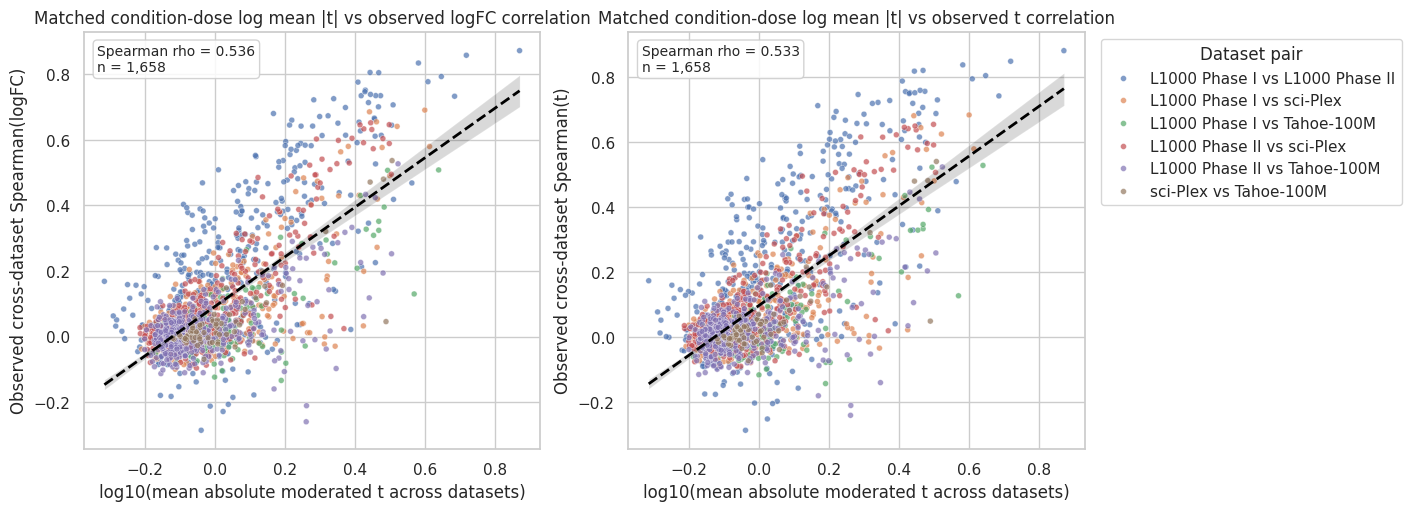

In [44]:
plot_frame = matched_condition_t_strength_summary.copy()
plot_frame = plot_frame.loc[
    np.isfinite(plot_frame["mean_pair_mean_abs_t"].to_numpy(dtype=float))
    & (plot_frame["mean_pair_mean_abs_t"].to_numpy(dtype=float) > 0)
].copy()
plot_frame["log10_mean_pair_mean_abs_t"] = np.log10(plot_frame["mean_pair_mean_abs_t"].to_numpy(dtype=float))
plot_frame["dataset_pair"] = plot_frame["dataset_a"].map(pretty_label) + " vs " + plot_frame["dataset_b"].map(pretty_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.scatterplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_logfc",
    hue="dataset_pair",
    alpha=0.7,
    s=18,
    ax=axes[0],
)
sns.regplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_logfc",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2.0, "linestyle": "--"},
    ax=axes[0],
)
logfc_rho = safe_column_spearman(plot_frame, "log10_mean_pair_mean_abs_t", "mean_observed_spearman_logfc")
logfc_subset = plot_frame[["log10_mean_pair_mean_abs_t", "mean_observed_spearman_logfc"]].replace([np.inf, -np.inf], np.nan).dropna()
axes[0].text(
    0.03,
    0.97,
    f"Spearman rho = {logfc_rho:.3f}\nn = {len(logfc_subset):,}",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
)
axes[0].set_title("Matched condition-dose log mean |t| vs observed logFC correlation")
axes[0].set_xlabel("log10(mean absolute moderated t across datasets)")
axes[0].set_ylabel("Observed cross-dataset Spearman(logFC)")

sns.scatterplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_t",
    hue="dataset_pair",
    alpha=0.7,
    s=18,
    ax=axes[1],
)
sns.regplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_t",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2.0, "linestyle": "--"},
    ax=axes[1],
)
t_rho = safe_column_spearman(plot_frame, "log10_mean_pair_mean_abs_t", "mean_observed_spearman_t")
t_subset = plot_frame[["log10_mean_pair_mean_abs_t", "mean_observed_spearman_t"]].replace([np.inf, -np.inf], np.nan).dropna()
axes[1].text(
    0.03,
    0.97,
    f"Spearman rho = {t_rho:.3f}\nn = {len(t_subset):,}",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
)
axes[1].set_title("Matched condition-dose log mean |t| vs observed t correlation")
axes[1].set_xlabel("log10(mean absolute moderated t across datasets)")
axes[1].set_ylabel("Observed cross-dataset Spearman(t)")

handles, labels = axes[1].get_legend_handles_labels()
if axes[0].legend_ is not None:
    axes[0].legend_.remove()
axes[1].legend(handles=handles, labels=labels, title="Dataset pair", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Optional cleanup:

```python
close_all_line_sources()
```
